We will first import the libraries and datasets that we intend to use

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from ml_from_scratch.supervised.decision_tree import DecisionTree

Now we will load the data that we need in order to test our model

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

If you remember our logistic regression testing on this same model, we had to scale the feature values. We don't have to do that this time because decision trees are not calculating weighted sums, they are just picking thresholds which do not act differently at scale. We will now train a decision tree on the data.

In [ ]:
tree = DecisionTree(min_samples_split=2, max_depth=5)
tree.train(X_train, y_train.reshape(-1, 1))

Note that training this took a fairly long time, almost as long as the multi-layer perceptron. This was also on a much smaller dataset. This algorithm can be very effective, however it is also pretty slow. Lets see how accurate the tree predicts the testing data.

In [4]:
preds = np.array(tree.predict(X_test))
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9298


Not bad, 93% is pretty accurate. Note however that for this dataset, logistic regression was faster and more accurate. A danger with decision trees is they can overfit data if given enough depth. I will demonstrate that now.

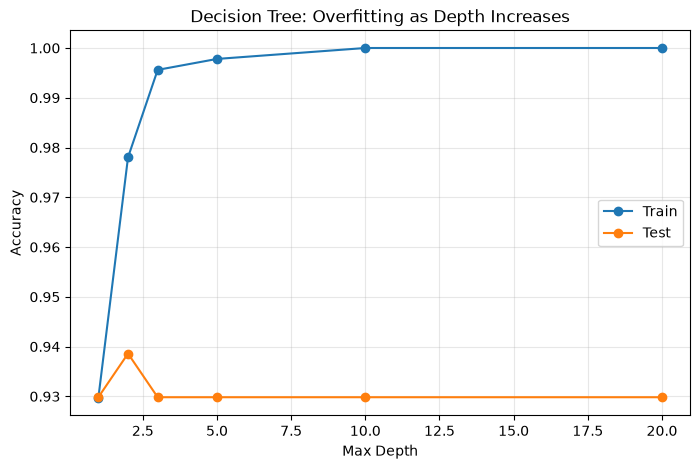

In [5]:
depths = [1, 2, 3, 5, 10, 20]
train_accs, test_accs = [], []

for depth in depths:
    t = DecisionTree(min_samples_split=2, max_depth=depth)
    t.train(X_train, y_train.reshape(-1, 1))
    train_accs.append(np.mean(np.array(t.predict(X_train)) == y_train))
    test_accs.append(np.mean(np.array(t.predict(X_test)) == y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker='o', label='Train')
plt.plot(depths, test_accs, marker='o', label='Test')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting as Depth Increases')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

Notice how even though the training data accuracy climbed very high as the depth increased, the test data stayed the same. Because of this, there was no need for a depth higher than 2 or 3 even though it seems to train better. We will also use the scikit classification report method on the decision tree once again.

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91        43
           1       0.96      0.93      0.94        71

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



This is lower than the logistic regression in all categories, however this dataset is very strong for logistic regression as it has a lot of different features to train on.